In [80]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "Finalterm" / "student_performance_updated_1000.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

In [81]:
data = pd.read_csv(data_path).drop(columns=['StudentID'])
data.head(3)

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False


In [82]:
print(data.shape)
print(data.info())


(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       966 non-null    object 
 1   Gender                     952 non-null    object 
 2   AttendanceRate             960 non-null    float64
 3   StudyHoursPerWeek          950 non-null    float64
 4   PreviousGrade              967 non-null    float64
 5   ExtracurricularActivities  957 non-null    float64
 6   ParentalSupport            978 non-null    object 
 7   FinalGrade                 960 non-null    float64
 8   Study Hours                976 non-null    float64
 9   Attendance (%)             959 non-null    float64
 10  Online Classes Taken       975 non-null    object 
dtypes: float64(7), object(4)
memory usage: 86.1+ KB
None


In [83]:
data[data['Name'].duplicated()]['Name'].value_counts()

Name
Andrea Frey          1
Kimberly Harrison    1
Erica Miller         1
Anthony Smith        1
Name: count, dtype: int64

In [84]:
data[data['Name']=='Andrea Frey'] 

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
45,Andrea Frey,Female,85.0,10.0,88.0,0.0,Low,92.0,1.3,100.0,True
681,Andrea Frey,Female,85.0,25.0,82.0,1.0,Medium,72.0,1.3,71.0,True


In [85]:
data[data['Name']=='Kimberly Harrison'] 

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
109,Kimberly Harrison,Male,91.0,15.0,86.0,NaN,Medium,92.0,3.0,72.0,True
812,Kimberly Harrison,NaN,92.0,17.0,77.0,3.0,Low,90.0,4.3,NaN,False


In [86]:
data[data['Name']=='Erica Miller'] 

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
946,Erica Miller,Male,85.0,10.0,90.0,0.0,Low,85.0,4.5,98.0,False
950,Erica Miller,Male,78.0,22.0,90.0,3.0,Low,80.0,4.4,100.0,False


In [87]:
data[data['Name']== 'Anthony Smith'] 

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
237,Anthony Smith,Male,92.0,30.0,90.0,0.0,Low,92.0,2.5,91.0,False
963,Anthony Smith,Male,85.0,25.0,60.0,0.0,High,90.0,3.3,64.0,False


In [88]:
data = data.drop(columns=['Name'])
data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0}).astype('Int64')
data

C:\Users\No\AppData\Local\Temp\ipykernel_11908\2588879728.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0}).astype('Int64')


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,0,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,1,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,1,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,0,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...
995,1,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,0,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,1,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [92]:
data['FinalGrade'].value_counts()

FinalGrade
72.0    110
78.0    104
80.0    102
92.0     97
85.0     97
90.0     96
62.0     95
87.0     94
68.0     88
88.0     77
Name: count, dtype: int64

<Axes: xlabel='FinalGrade', ylabel='Study Hours'>

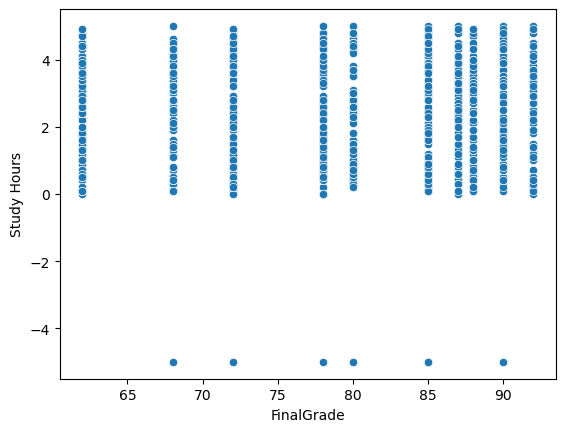

In [91]:
sns.scatterplot(data, x='FinalGrade', y='Study Hours')